# Exploratory Data Analysis

The purpose of this notebook is to analyze the data we have collected, including the distribution of sets according to DJs and the number of DJ Sets with media track links and suggestions.

### A note on Nomenclature
A set is too ambiguous (mathematical set or tracklist set?). We refer to **each tracklist as a DJ Set**, and **each row within the DJ Set as a DJ Set Row.** Correspondingly, we refer to the **media links for a tracklist as the DJ Set Media Link** and refer to the **media links for each track as the DJ Set Row Media Link.**
Correspondingly, the DJs who created the DJ Sets are referred to as **Artists.** each DJ Set has at least one Artist, and multiple Artists may create the same DJ Set (there exist more fine-grained indicators of who played which DJ Set Row within the `dj_set_rows` table).
A Media Link Platform refers to a platform that provides the audio. Such platforms include Spotify, Soundcloud, Apple Music, and Beatport. 

### Database Tables

We have seven tables. Their names, functionality, and rows are listed below:


### Database Schema

| Table Name | Row Count | Columns | Description |
| :--- | :--- | :--- | :--- |
| **`dj_set_crawls`** | 41,492 | `crawl_id`, `set_id`, `set_url`, `fetched_at`, `http_status`, `etag`, `last_modified`, `html_sha256`, `html_path` | Metadata for the crawl itself pertaining to a DJ Set. We do not have a retry mechanism yet and on errors we write to the `scrape_failures` table, so there is a one-to-one correspondence between crawl and DJ Set. |
| **`dj_set_media_links`** | 50,537 | `media_link_id`, `set_id`, `platform`, `url`, `id_item`, `id_source`, `scraped_at` | The DJ Set media links. Each row pertains to a single DJ Set and Media Link Platform. Each DJ Set may have multiple media links. We scrape all of the media links available. |
| **`dj_set_rows`** | 1,401,879 | `row_id`, `set_id`, `row_index`, `element_id`, `classes`, `data_attrs_json`, `text_excerpt`, `raw_html`, `scraped_at` | The DJ Set Rows. Each `set_id` pertains to the set it is in, and the `row_id` pertains to the row it is. Note this is untyped and includes suggestions, regular tracks, and hidden tracks. |
| **`dj_set_track_media_links`** | 2,028,721 | `track_media_id`, `set_id`, `tlp_id`, `track_id`, `platform`, `player_id`, `id_object`, `id_item`, `id_source`, `view_source`, `view_item`, `scraped_at` | The DJ Set Row media links. Each row pertains to a single track and Media Link Platform (youtube, spotify, etc.) Each track may have multiple media links. The hierarchy for scraping Media links is given in the `/web_crawler` folder. |
| **`dj_sets`** | 41,492 | `set_id`, `set_url`, `title`, `date_played`, `artists`, `creator_name`, `creator_url`, `views`, `ided_tracks`, `total_tracks`, `likes`, `play_time`, `styles`, `scraped_at` | The DJ Set and its metadata; mirrors the data in the JSON. |
| **`scrape_failures`** | 6,125 | `failure_id`, `set_id`, `set_url`, `stage`, `track_title`, `track_id`, `tlp_id`, `params_json`, `error`, `created_at` | Lists the errors encountered while scraping. The error is given by the `error` column. Usually the error is due to AJAX failure for getting the DJ Set Row media link. |
| **`sqlite_sequence`** | 5 | `name`, `seq` | internal table SQLite uses to keep track of auto-incrementing IDs |

In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from common import (
    get_dj_metadata_df,
    get_dj_sets_with_at_least_one_dj_set_media_link,
    get_dj_set_rows_with_at_least_one_dj_set_media_link,
    get_dj_set_row_media_links_with_dj_set_media_links,
    get_dj_sets_without_suggestions,
    get_dj_set_rows_without_suggestions,
    get_dj_set_row_media_links_without_suggestions,
)

REPO_ROOT = Path("/Users/johnnycabrahams/Desktop/tracklist_engine")
DB_PATH   = REPO_ROOT / "data" / "db" / "music_database.db"
JSON_DIR  = REPO_ROOT / "data" / "djs"
HTML_DIR  = REPO_ROOT / "data" / "html"

conn = sqlite3.connect(str(DB_PATH))
cur  = conn.cursor()
print(f'connected: {DB_PATH}')

connected: /Users/johnnycabrahams/Desktop/tracklist_engine/data/db/music_database.db


### Database Information
Get the general information regarding our database. It was used for the Database Schema table above.

In [2]:
# 1. Get all the table names first
cur.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name;
""")
tables = cur.fetchall()

print("--- Database Schema & Row Counts ---")

# 2. Loop through each table
for table in tables:
    table_name = table[0]
    
    # Get the total row count for this specific table
    cur.execute(f'SELECT COUNT(*) FROM "{table_name}"')
    row_count = cur.fetchone()[0]
    
    # Get the column information for this table
    cur.execute(f'PRAGMA table_info("{table_name}")')
    columns_info = cur.fetchall()
    
    # PRAGMA returns a list of tuples: (cid, name, type, notnull, dflt_value, pk)
    # We just want the 'name' (which is at index 1)
    column_names = [col[1] for col in columns_info]
    
    # Print the results nicely formatted
    print(f"\nTable: {table_name}")
    print(f"Rows:  {row_count}")
    print(f"Cols:  {', '.join(column_names)}")
    print("-" * 50)

--- Database Schema & Row Counts ---

Table: dj_set_crawls
Rows:  41492
Cols:  crawl_id, set_id, set_url, fetched_at, http_status, etag, last_modified, html_sha256, html_path
--------------------------------------------------

Table: dj_set_media_links
Rows:  50537
Cols:  media_link_id, set_id, platform, url, id_item, id_source, scraped_at
--------------------------------------------------



Table: dj_set_rows
Rows:  1401879
Cols:  row_id, set_id, row_index, element_id, classes, data_attrs_json, text_excerpt, raw_html, scraped_at
--------------------------------------------------



Table: dj_set_track_media_links
Rows:  2028721
Cols:  track_media_id, set_id, tlp_id, track_id, platform, player_id, id_object, id_item, id_source, view_source, view_item, scraped_at
--------------------------------------------------

Table: dj_sets
Rows:  41492
Cols:  set_id, set_url, title, date_played, artists, creator_name, creator_url, views, ided_tracks, total_tracks, likes, play_time, styles, scraped_at
--------------------------------------------------

Table: scrape_failures
Rows:  6125
Cols:  failure_id, set_id, set_url, stage, track_title, track_id, tlp_id, params_json, error, created_at
--------------------------------------------------

Table: sqlite_sequence
Rows:  5
Cols:  name, seq
--------------------------------------------------


### DJ Analysis
Analyze DJ Sets (not DJ Set Rows).

First, we count the number of DJ Sets for each Artist

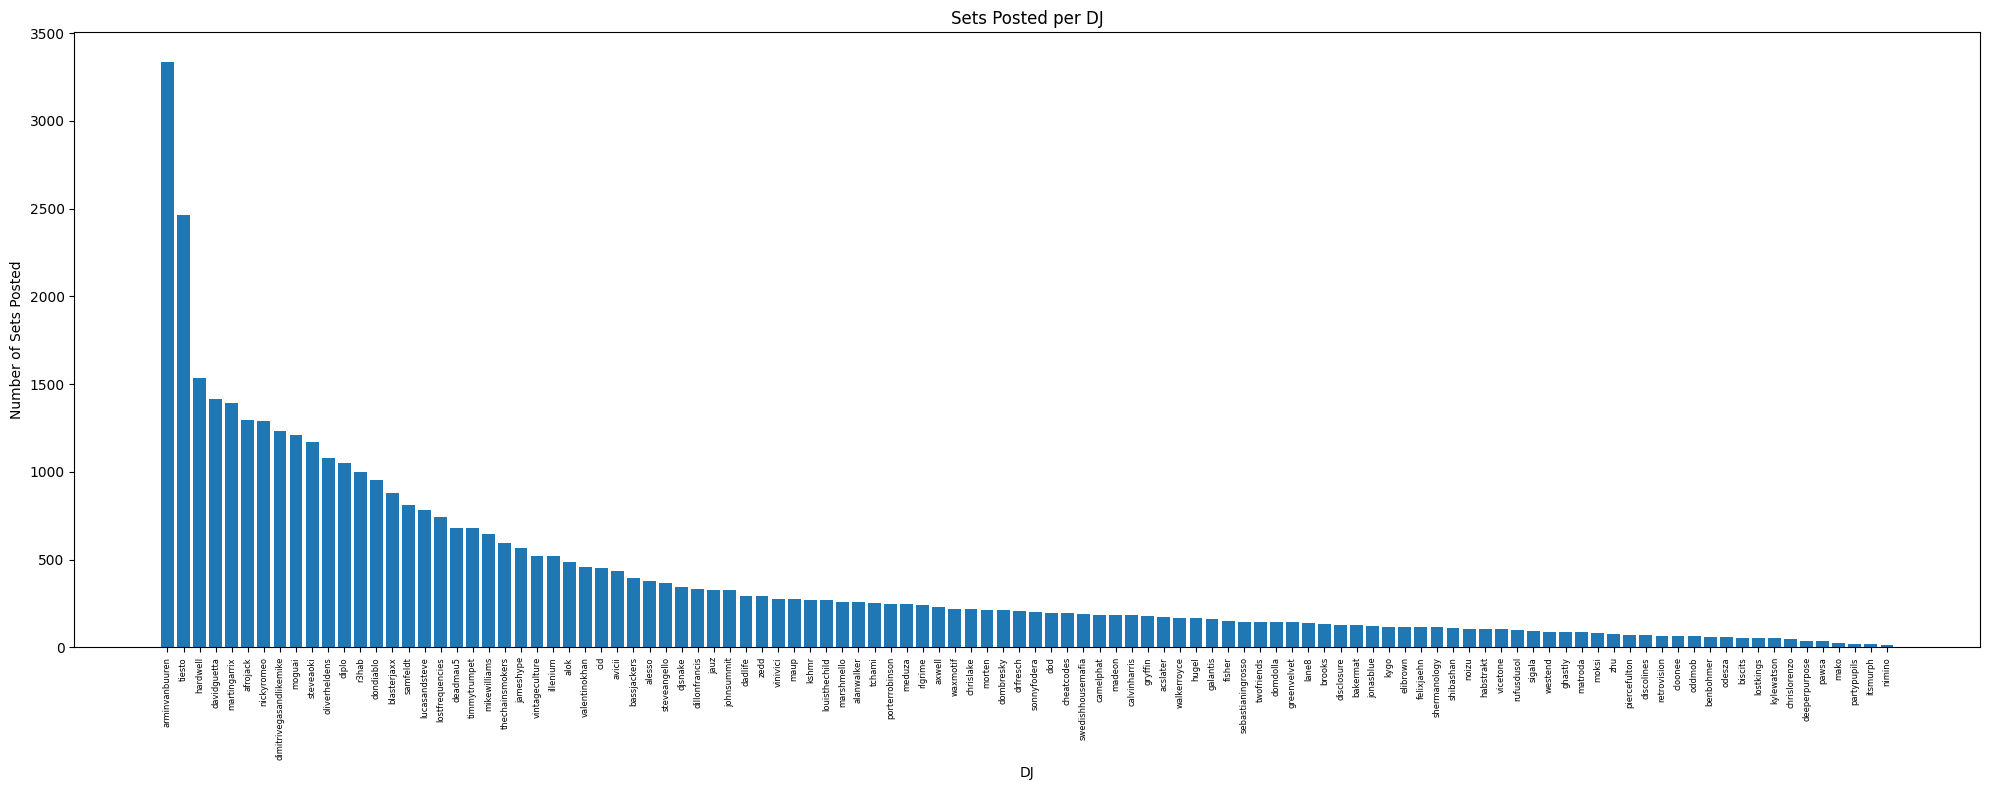

In [3]:
dj_set_jsons_df = get_dj_metadata_df(JSON_DIR)

# Count number of sets per artist
sets_per_artist = dj_set_jsons_df.groupby("artist_name").size().sort_values(ascending=False)

plt.figure(figsize=(20, 8))  # widen figure
plt.bar(sets_per_artist.index, sets_per_artist.values)

plt.xticks(rotation=90, fontsize=6)  # small font to fit more names
plt.xlabel("DJ")
plt.ylabel("Number of Sets Posted")
plt.title("Sets Posted per DJ")

plt.tight_layout()

plt.savefig("sets_per_artist.png", dpi=300, bbox_inches="tight")

plt.show()

### Analyzing Noisy Data

In [4]:
dj_sets_with_at_least_one_dj_set_media_link = get_dj_sets_with_at_least_one_dj_set_media_link(conn)
print(f"Number of DJ sets with at least one media link: {dj_sets_with_at_least_one_dj_set_media_link.shape[0]}")

dj_set_rows_with_at_least_one_dj_set_media_link = get_dj_set_rows_with_at_least_one_dj_set_media_link(conn)
print(f"Number of DJ set rows belonging to a dj set with at least one media link: {dj_set_rows_with_at_least_one_dj_set_media_link.shape[0]}")

dj_set_rows_media_links_with_dj_set_links_df = get_dj_set_row_media_links_with_dj_set_media_links(conn)
print(f"Number of DJ Set Row Media Links for DJ Sets with at least one DJ Set Media Link: {dj_set_rows_media_links_with_dj_set_links_df.shape[0]}")

dj_sets_without_suggestions = get_dj_sets_without_suggestions(conn)
print(f"Number of DJ Sets with at least one media link and no suggestions: {dj_sets_without_suggestions.shape[0]}")

dj_set_rows_without_suggestions = get_dj_set_rows_without_suggestions(conn)
print(f"Number of DJ Set Rows belonging to DJ Sets with at least one media link and no suggestions: {dj_set_rows_without_suggestions.shape[0]}")

dj_set_row_media_links_without_suggestions = get_dj_set_row_media_links_without_suggestions(conn)
print(f"Number of DJ Set Row Media Links belonging to DJ Sets with at least one media link and no suggestions: {dj_set_row_media_links_without_suggestions.shape[0]}")

Number of DJ sets with at least one media link: 29902


Number of DJ set rows belonging to a dj set with at least one media link: 1044681


Number of DJ Set Row Media Links for DJ Sets with at least one DJ Set Media Link: 1524466


Number of DJ Sets with at least one media link and no suggestions: 27144


Number of DJ Set Rows belonging to DJ Sets with at least one media link and no suggestions: 916953


Number of DJ Set Row Media Links belonging to DJ Sets with at least one media link and no suggestions: 1352881


Now we determine the number of rows with and without suggestions.

### Scrape failures

Where does scraping fail? The `scrape_failures` table logs errors keyed by the
pipeline `stage` (`page_load`, `scrape`, `ajax`, `db`). `ajax` failures matter
most for us — they mean a track row exists in `dj_set_rows` but we never
fetched its per-track media link, so that track can't feed the audio pipeline
without a retry.

total failures logged: 6,125

by stage:
stage
ajax    6125

distinct sets with any failure: 5,447


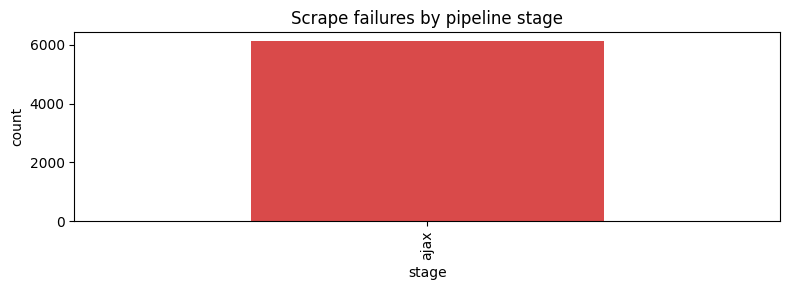

In [5]:
failures = pd.read_sql_query(
    "SELECT stage, error, set_id FROM scrape_failures", conn
)
print(f'total failures logged: {len(failures):,}')
print('\nby stage:')
print(failures.stage.value_counts().to_string())
print(f'\ndistinct sets with any failure: {failures.set_id.nunique():,}')

fig, ax = plt.subplots(figsize=(8, 3))
failures.stage.value_counts().plot(kind='bar', ax=ax, color='#d94a4a')
ax.set_title('Scrape failures by pipeline stage')
ax.set_ylabel('count')
plt.tight_layout(); plt.show()

In [6]:
# Top error messages — which failure modes are worth fixing first?
top_errors = (
    failures.assign(error=failures['error'].fillna('').str.slice(0, 120))
            .groupby('error').size().sort_values(ascending=False).head(10)
)
print(top_errors.to_string())

error
APIRequestContext.get: socket hang up\nCall log:\n  - → GET https://www.1001tracklists.com/ajax/get_medialink.php?idObject    6093
APIRequestContext.get: connect ECONNREFUSED 158.69.5.7:443\nCall log:\n  - → GET https://www.1001tracklists.com/ajax/get_m      31
APIRequestContext.get: read ECONNRESET\nCall log:\n  - → GET https://www.1001tracklists.com/ajax/get_medialink.php?idObjec       1


### Platform coverage across the corpus

Which streaming platforms dominate as a source of audio? This drives the
download-strategy decision (yt-dlp vs spotdl vs skip).

  platform  links  distinct_tracks
   youtube 852605           125342
   spotify 821892           138776
soundcloud  24294            10034
     apple   2887              615


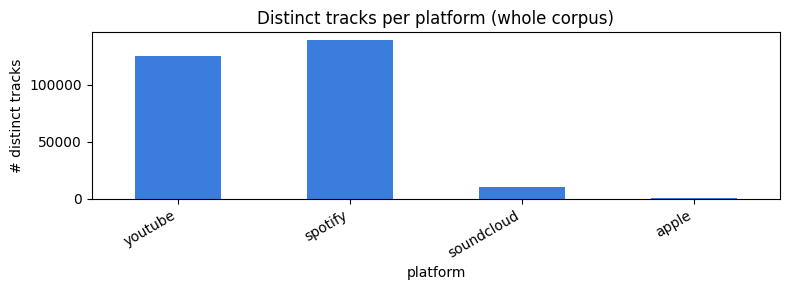

In [7]:
platform_counts = pd.read_sql_query(
    """
    SELECT platform, COUNT(*) AS links, COUNT(DISTINCT track_id) AS distinct_tracks
    FROM dj_set_track_media_links
    WHERE track_id IS NOT NULL AND track_id != ''
    GROUP BY platform
    ORDER BY links DESC
    """,
    conn,
)
print(platform_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
platform_counts.set_index('platform')['distinct_tracks'].plot(kind='bar', ax=ax, color='#3b7ddd')
ax.set_title('Distinct tracks per platform (whole corpus)')
ax.set_ylabel('# distinct tracks')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

### Average Length of a Set

Now, we would like to analyze the general structure of the sets. The sets can be abstracted into a graph, where "w/" and "hidden" variables pertain to leaves in the graph. We want to analyze this structure. 

Before we can do that, however, we need to turn our raw text signals into structured data using a tokenizer. See `tokenizer.ipynb` for the corresponding implementation.

total_tracks : mean=25.2  median=19.0  p90=46  max=950
n_rows       : mean=33.8  median=24.0  p90=64  max=1201


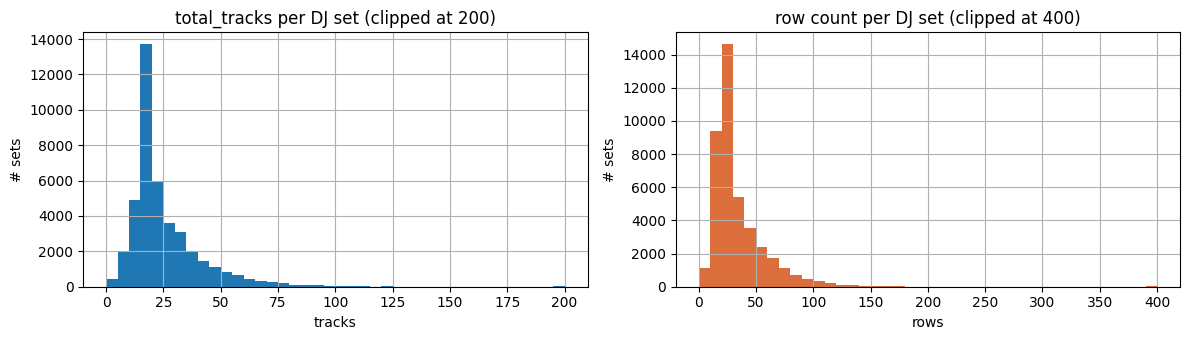

In [8]:
# Sets-wide: distribution of total_tracks and row counts per set
import matplotlib.pyplot as plt
import pandas as pd

sets_df = pd.read_sql_query("SELECT set_id, title, total_tracks, ided_tracks, play_time FROM dj_sets", conn)
rows_per_set = pd.read_sql_query("SELECT set_id, COUNT(*) AS n_rows FROM dj_set_rows GROUP BY set_id", conn)
sets_df = sets_df.merge(rows_per_set, on='set_id', how='left').fillna({'n_rows': 0})

print('total_tracks : mean={:.1f}  median={}  p90={}  max={}'.format(
    sets_df.total_tracks.mean(), sets_df.total_tracks.median(),
    int(sets_df.total_tracks.quantile(0.9)), int(sets_df.total_tracks.max())))
print('n_rows       : mean={:.1f}  median={}  p90={}  max={}'.format(
    sets_df.n_rows.mean(), sets_df.n_rows.median(),
    int(sets_df.n_rows.quantile(0.9)), int(sets_df.n_rows.max())))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sets_df.total_tracks.clip(upper=200).hist(bins=40, ax=axes[0])
axes[0].set_title('total_tracks per DJ set (clipped at 200)')
axes[0].set_xlabel('tracks'); axes[0].set_ylabel('# sets')

sets_df.n_rows.clip(upper=400).hist(bins=40, ax=axes[1], color='#db6e3b')
axes[1].set_title('row count per DJ set (clipped at 400)')
axes[1].set_xlabel('rows'); axes[1].set_ylabel('# sets')
plt.tight_layout(); plt.show()


Sets are long-tailed: most sit in the 40–80 track range but the
upper tail runs into hundreds — festival sets and mashup series like
Big Bootie and Hardwell's On Air pull the right side out.


### Big Bootie as a pilot dataset

We focus the audio-alignment work on Two Friends' **Big Bootie Mix** series
because it combines every hard case we care about — dense mashups, short
track segments, acappella/instrumental overlays, occasional loops — while
being almost fully IDed and well-linked to downloadable media. These cells
summarize what that slice looks like compared to the broader corpus.


In [9]:
# Big Bootie slice — high-level
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from big_bootie import load_big_bootie_sets, load_big_bootie_rows, load_big_bootie_track_media_links, tokenize_rows

bb_sets = load_big_bootie_sets(conn)
bb_rows = load_big_bootie_rows(conn)
bb_tml  = load_big_bootie_track_media_links(conn)

print('Big Bootie:')
print(f'  {len(bb_sets)} sets across volumes {sorted(bb_sets.volume.dropna().astype(int).unique())}')
print(f'  {len(bb_rows):,} rows  ({len(bb_rows) / len(bb_sets):.1f} rows/set avg)')
print(f'  {len(bb_tml):,} track media links')
print()
print('Compared to corpus: Big Bootie is {:.2%} of rows, {:.2%} of media links'.format(
    len(bb_rows) / pd.read_sql_query('SELECT COUNT(*) AS c FROM dj_set_rows', conn).c[0],
    len(bb_tml)  / pd.read_sql_query('SELECT COUNT(*) AS c FROM dj_set_track_media_links', conn).c[0],
))


Big Bootie:
  30 sets across volumes [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
  5,263 rows  (175.4 rows/set avg)
  8,646 track media links



Compared to corpus: Big Bootie is 0.38% of rows, 0.43% of media links


In [10]:
# Platform coverage of the Big Bootie slice
coverage = (
    bb_tml.dropna(subset=['track_id'])
          .assign(one=1)
          .pivot_table(index='track_id', columns='platform', values='one', aggfunc='max', fill_value=0)
)
n_tracks = len(coverage)
print(f'Distinct canonical tracks: {n_tracks}')
for col in ('youtube','soundcloud','spotify','apple'):
    if col in coverage.columns:
        print(f'  on {col:10s}: {int(coverage[col].sum()):4d}  ({coverage[col].mean()*100:.1f}%)')

downloadable = int(((coverage.get('youtube', 0) + coverage.get('soundcloud', 0)) > 0).sum())
print(f'\nDownloadable (YT or SC): {downloadable}  ({downloadable/n_tracks*100:.1f}%)')


Distinct canonical tracks: 3265
  on youtube   : 2865  (87.7%)
  on soundcloud:   69  (2.1%)
  on spotify   : 3021  (92.5%)
  on apple     :   12  (0.4%)

Downloadable (YT or SC): 2934  (89.9%)


### Tokenized structural stats

Pulling the tokenized Big Bootie rows back in to size up the mashup load.


In [11]:
bb_tokens = tokenize_rows(bb_rows)
tracks = bb_tokens[bb_tokens.row_kind == 'track']

per_set = (
    tracks.groupby('set_id')
          .agg(track_rows=('row_index','size'),
               distinct_cues=('cue_seconds_section', 'nunique'),
               pct_ided=('is_ided', lambda s: s.fillna(False).mean()*100),
               pct_concurrent=('is_concurrent', lambda s: s.fillna(False).mean()*100),
               pct_remixish=('is_remixish', lambda s: s.fillna(False).mean()*100))
          .join(bb_sets.set_index('set_id')[['volume','date_played']])
          .sort_values('volume')
)
per_set['layer_ratio'] = per_set['track_rows'] / per_set['distinct_cues'].where(per_set['distinct_cues'] > 0)
per_set.round(1)

/var/folders/b3/vg6l_zw95fddlqg59z441xk80000gn/T/ipykernel_63919/4088422796.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pct_ided=('is_ided', lambda s: s.fillna(False).mean()*100),
/var/folders/b3/vg6l_zw95fddlqg59z441xk80000gn/T/ipykernel_63919/4088422796.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pct_concurrent=('is_concurrent', lambda s: s.fillna(False).mean()*100),
/var/folders/b3/vg6l_zw95fddlqg59z441xk80000gn/T/ipykernel_63919/4088422796.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated a

,track_rows,distinct_cues,pct_ided,pct_concurrent,pct_remixish,volume,date_played,layer_ratio
set_id,,,,,,,,
1kh4dbd1,51,48,96.1,3.9,60.8,1.0,2012-05-31,1.1
qgvujwt,65,59,95.4,3.1,47.7,2.0,2012-11-03,1.1
2ckm8bjk,56,53,100.0,1.8,51.8,3.0,2013-03-19,1.1
4fjz021,64,0,100.0,20.3,56.2,4.0,2013-08-15,NaN
hy83dh1,72,0,97.2,2.8,56.9,5.0,2014-02-18,NaN
3b0k6zk,69,18,100.0,50.7,65.2,6.0,2014-08-18,3.8
66wusst,101,89,95.0,73.3,70.3,7.0,2015-04-07,1.1
8ktvhkt,124,30,96.8,77.4,71.8,8.0,2015-09-28,4.1
1n81jy3k,130,129,100.0,71.5,69.2,9.0,2016-04-20,1.0


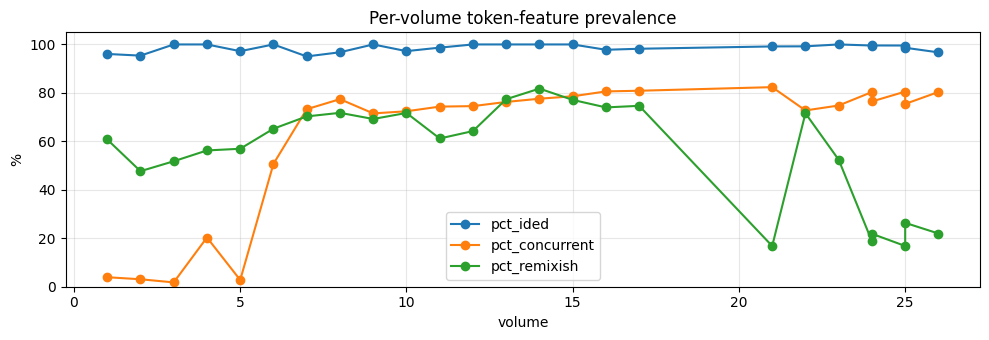

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.5))
per_set.sort_values('volume').plot(
    x='volume',
    y=['pct_ided','pct_concurrent','pct_remixish'],
    marker='o', ax=ax,
)
ax.set_title('Per-volume token-feature prevalence')
ax.set_ylabel('%'); ax.set_xlabel('volume'); ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### What this means for the pipeline

- **is_concurrent rate climbs** as the series matures — later volumes rely more heavily on mashup stacking, which is exactly the signal the cutup-plan alignment is meant to model.
- **is_ided stays near 100%** — reference tracks exist for nearly every entry, so MERT can be computed once per canonical recording and reused.
- **is_remixish is a smaller share** but non-trivial; for those we'll still need the transposition/tempo adapter because the played audio is a remix variant of the reference.

Next: run the audio download for a single volume (e.g. Vol. 26) via
`python -m audio_pipeline.main --set-id 1d9zwh49`, then wire up stems +
cue-detr + essentia analyzers.
